# StaySure Hotel Cancellation ML
## Milestone 5 — Decision Trees and Random Forests

**Business goal:** determine whether nonlinear tree models improve cancellation prediction beyond the Milestone 4 logistic-regression baseline.

This learner-led notebook trains one interpretable decision tree and one random forest. It compares validation performance, measures overfitting, and explains which transformed features drive the strongest tree model. Models learn only from the chronological training period; the test set remains sealed.

### Main outputs

- `models/random_forest_candidate.joblib` — local fitted tree-model candidate (ignored by Git)
- `reports/milestone_05_model_comparison.csv` — validation metrics for all three models
- `reports/milestone_05_overfitting_check.csv` — train-versus-validation performance gaps
- `reports/milestone_05_feature_importance.csv` — ranked random-forest feature importances


### What you should be able to explain afterward

1. How a decision tree creates nonlinear decision rules.
2. Why an unrestricted tree tends to overfit.
3. How a random forest reduces the variance of one tree.
4. Why train-versus-validation gaps matter.
5. How to interpret impurity-based feature importance carefully.
6. Why the validation set—not the sealed test set—is used for model comparison.


## 1. Setup


In [1]:
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
RANDOM_STATE = 42
print("Libraries loaded.")


Libraries loaded.


In [2]:
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
CLEAN_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "hotel_bookings_clean.csv"
PREPROCESSOR_PATH = PROJECT_ROOT / "models" / "preprocessing_pipeline.joblib"
BASELINE_MODEL_PATH = PROJECT_ROOT / "models" / "logistic_regression_baseline.joblib"
FEATURE_MANIFEST_PATH = PROJECT_ROOT / "reports" / "milestone_03_feature_manifest.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)


Project root: C:\Users\theko\ML_Projects\staysure-hotel-cancellation-ml


## 2. Recreate the established chronological split


In [3]:
required_paths = [
    CLEAN_DATA_PATH, PREPROCESSOR_PATH, BASELINE_MODEL_PATH, FEATURE_MANIFEST_PATH,
]
for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required earlier-milestone artifact not found: {required_path}"
        )

df = pd.read_csv(CLEAN_DATA_PATH)
manifest = pd.read_csv(FEATURE_MANIFEST_PATH)
FEATURE_COLUMNS = manifest["source_feature"].tolist()
TARGET = "is_canceled"

month_number = {month: number for number, month in enumerate([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
], start=1)}
df["arrival_date"] = pd.to_datetime({
    "year": df["arrival_date_year"],
    "month": df["arrival_date_month"].map(month_number),
    "day": df["arrival_date_day_of_month"],
})
df = df.sort_values("arrival_date").reset_index(drop=True)

train_df = df[df["arrival_date"] <= "2017-02-10"].copy()
valid_df = df[
    (df["arrival_date"] > "2017-02-10")
    & (df["arrival_date"] <= "2017-05-21")
].copy()
test_df = df[df["arrival_date"] > "2017-05-21"].copy()

X_train, y_train = train_df[FEATURE_COLUMNS].copy(), train_df[TARGET].copy()
X_valid, y_valid = valid_df[FEATURE_COLUMNS].copy(), valid_df[TARGET].copy()

print("Train:", X_train.shape, f"cancellation rate={y_train.mean():.2%}")
print("Validation:", X_valid.shape, f"cancellation rate={y_valid.mean():.2%}")
print("Test (sealed):", test_df.shape)


Train: (82937, 27) cancellation rate=36.30%
Validation: (17758, 27) cancellation rate=39.47%
Test (sealed): (17869, 29)


The test rows are counted only to confirm that the split still exists. They are not assigned to feature or target variables, transformed, predicted, or scored in this milestone.


## 3. Apply the fitted Milestone 3 preprocessing pipeline


In [4]:
preprocessor = joblib.load(PREPROCESSOR_PATH)
X_train_ready = preprocessor.transform(X_train)
X_valid_ready = preprocessor.transform(X_valid)
feature_names = preprocessor.get_feature_names_out()

assert X_train_ready.shape[1] == X_valid_ready.shape[1] == len(feature_names)
assert X_train_ready.shape[0] == len(y_train)
assert X_valid_ready.shape[0] == len(y_valid)
print("Train matrix:", X_train_ready.shape)
print("Validation matrix:", X_valid_ready.shape)
print("Test data was not transformed or evaluated.")


Train matrix: (82937, 522)
Validation matrix: (17758, 522)
Test data was not transformed or evaluated.


## 4. Define consistent evaluation helpers


### TODO 1 — Complete the evaluation function


In [5]:
def classification_metrics(model_name, split_name, y_true, y_pred, y_probability):
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        # TODO 1: Replace each None with the matching metric call.
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
    }


def evaluate_on_split(model, model_name, split_name, X, y):
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]
    return classification_metrics(
        model_name, split_name, y, predictions, probabilities
    )

print("Evaluation helpers defined. Complete TODO 1 before training models.")


Evaluation helpers defined. Complete TODO 1 before training models.


<details>
<summary>Hint for TODO 1</summary>

Use `precision_score`, `recall_score`, `f1_score`, and `roc_auc_score`. Add `zero_division=0` to the first three classification metrics where appropriate.
</details>


## 5. Train a controlled decision tree


A decision tree can capture interactions and nonlinear thresholds without manually creating interaction terms. Depth and leaf-size controls prevent it from memorizing tiny groups of training rows.


### TODO 2 — Configure the decision tree


In [6]:
# TODO 2: Use max_depth=12 and min_samples_leaf=20.
TREE_MAX_DEPTH = 12
TREE_MIN_SAMPLES_LEAF = 20

if TREE_MAX_DEPTH is None or TREE_MIN_SAMPLES_LEAF is None:
    print("TODO 2: Set both decision-tree controls before continuing.")
    decision_tree = None
else:
    decision_tree = DecisionTreeClassifier(
        max_depth=TREE_MAX_DEPTH,
        min_samples_leaf=TREE_MIN_SAMPLES_LEAF,
        random_state=RANDOM_STATE,
    )
    started = perf_counter()
    decision_tree.fit(X_train_ready, y_train)
    tree_fit_seconds = perf_counter() - started
    print(f"Decision tree fitted in {tree_fit_seconds:.2f} seconds.")


Decision tree fitted in 4.96 seconds.


**Explain:** What would likely happen to training and validation performance if `max_depth=None` and `min_samples_leaf=1`?

The tree could keep splitting until leaves are very pure, so training performance would usually rise while the gap to validation performance would widen. That is classic high-variance overfitting

<details>
<summary>Suggested explanation</summary>

The tree could keep splitting until leaves are very pure, so training performance would usually rise while the gap to validation performance would widen. That is classic high-variance overfitting.
</details>


### Visualize only the first three tree levels


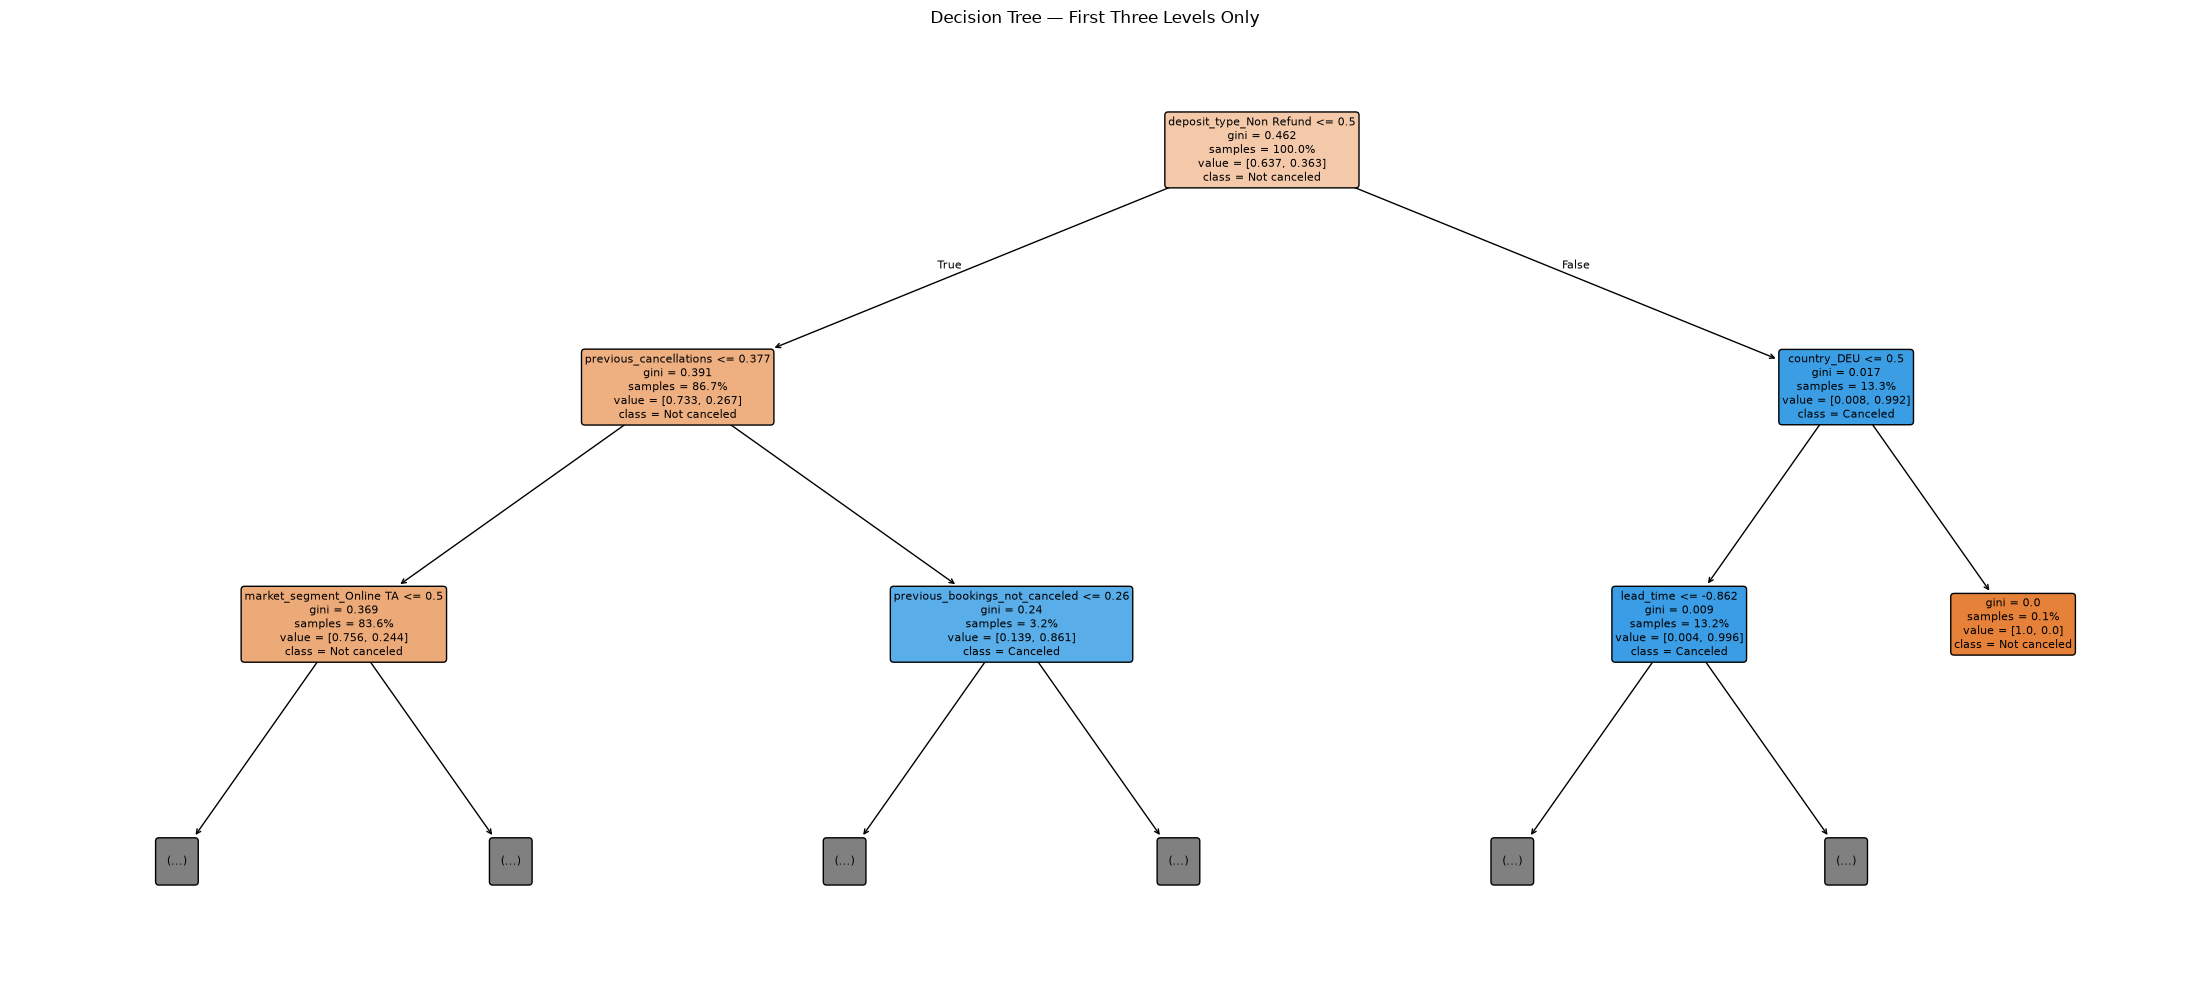

In [7]:
if decision_tree is None:
    print("Complete TODO 2 first.")
else:
    plt.figure(figsize=(22, 10))
    plot_tree(
        decision_tree,
        feature_names=feature_names,
        class_names=["Not canceled", "Canceled"],
        filled=True,
        rounded=True,
        max_depth=2,
        proportion=True,
        fontsize=8,
    )
    plt.title("Decision Tree — First Three Levels Only")
    plt.tight_layout()
    plt.show()


The full fitted tree is deeper than this image. Limiting the plot keeps the top decision rules readable; it does not change the model.


## 6. Measure decision-tree overfitting


### TODO 3 — Evaluate both training and validation data


In [8]:
if decision_tree is None:
    print("Complete TODO 2 first.")
else:
    # TODO 3: Replace None with X_train_ready and X_valid_ready.
    TREE_TRAIN_MATRIX = X_train_ready
    TREE_VALID_MATRIX = X_valid_ready

    if TREE_TRAIN_MATRIX is None or TREE_VALID_MATRIX is None:
        print("TODO 3: Assign the correct transformed matrices.")
    else:
        tree_train_metrics = evaluate_on_split(
            decision_tree, "Decision tree", "train", TREE_TRAIN_MATRIX, y_train
        )
        tree_valid_metrics = evaluate_on_split(
            decision_tree, "Decision tree", "validation", TREE_VALID_MATRIX, y_valid
        )
        display(pd.DataFrame([tree_train_metrics, tree_valid_metrics]))


,model,split,accuracy,precision,recall,f1,roc_auc
0,Decision tree,train,0.8750,0.8368,0.8145,0.8255,0.9460
1,Decision tree,validation,0.7974,0.7141,0.8120,0.7599,0.8854


**Interpret:** Is this controlled tree overfitting? Support your answer with at least one train-versus-validation gap.

## DECISION TREE - OVERFITTING
The controlled decision tree shows moderate overfitting. Its training F1 score is 0.8255 compared with 0.7599 on validation data, producing a gap of 0.0656. Its training ROC AUC is 0.9460 compared with 0.8854 on validation data, producing a gap of 0.0606. The model performs better on training data, but the validation results remain strong, suggesting that the depth and leaf-size controls reduced—but did not eliminate—overfitting.


## 7. Train a random forest


A random forest trains many trees on resampled rows and randomized feature subsets, then averages their predictions. This often reduces the instability of a single tree. `class_weight="balanced"` gives the minority class more influence during fitting.


### TODO 4 — Configure the ensemble


In [9]:
# TODO 4: Use 100 estimators, max_depth=18, min_samples_leaf=5,
# max_features=0.5, and class_weight="balanced".
FOREST_ESTIMATORS = 100
FOREST_MAX_DEPTH = 18
FOREST_MIN_SAMPLES_LEAF = 5
FOREST_MAX_FEATURES = 0.5
FOREST_CLASS_WEIGHT = "balanced"

forest_settings = [
    FOREST_ESTIMATORS, FOREST_MAX_DEPTH, FOREST_MIN_SAMPLES_LEAF,
    FOREST_MAX_FEATURES, FOREST_CLASS_WEIGHT,
]
if any(value is None for value in forest_settings):
    print("TODO 4: Complete all five random-forest settings.")
    random_forest = None
else:
    random_forest = RandomForestClassifier(
        n_estimators=FOREST_ESTIMATORS,
        max_depth=FOREST_MAX_DEPTH,
        min_samples_leaf=FOREST_MIN_SAMPLES_LEAF,
        max_features=FOREST_MAX_FEATURES,
        class_weight=FOREST_CLASS_WEIGHT,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    started = perf_counter()
    random_forest.fit(X_train_ready, y_train)
    forest_fit_seconds = perf_counter() - started
    print(f"Random forest fitted in {forest_fit_seconds:.2f} seconds.")


Random forest fitted in 49.36 seconds.


<details>
<summary>Why these settings?</summary>

They are intentionally modest, reproducible starting values—not the result of test-set tuning. The depth and leaf controls regularize each tree; using 100 estimators stabilizes the ensemble while keeping notebook runtime reasonable.
</details>


## 8. Compare against the saved logistic baseline


### TODO 5 — Evaluate all models consistently


In [10]:
if random_forest is None or decision_tree is None:
    print("Complete TODOs 2–4 first.")
else:
    logistic_model = joblib.load(BASELINE_MODEL_PATH)

    logistic_train_metrics = evaluate_on_split(
        logistic_model, "Logistic regression", "train", X_train_ready, y_train
    )
    logistic_valid_metrics = evaluate_on_split(
        logistic_model, "Logistic regression", "validation", X_valid_ready, y_valid
    )
    forest_train_metrics = evaluate_on_split(
        random_forest, "Random forest", "train", X_train_ready, y_train
    )
    forest_valid_metrics = evaluate_on_split(
        random_forest, "Random forest", "validation", X_valid_ready, y_valid
    )

    # TODO 5: Put the three validation dictionaries inside this list.
    validation_rows = [
        logistic_valid_metrics,
        tree_valid_metrics,
        forest_valid_metrics,
    ]
    if validation_rows is None:
        print("TODO 5: Add logistic, tree, and forest validation metrics.")
    else:
        model_comparison = (
            pd.DataFrame(validation_rows)
            .drop(columns="split")
            .sort_values(["roc_auc", "f1"], ascending=False)
            .reset_index(drop=True)
        )
        display(model_comparison)


,model,accuracy,precision,recall,f1,roc_auc
0,Random forest,0.8107,0.7616,0.7576,0.7596,0.8985
1,Decision tree,0.7974,0.7141,0.8120,0.7599,0.8854
2,Logistic regression,0.7960,0.7632,0.7004,0.7305,0.8753


**Interpret:** Which model would you carry forward, and why? Discuss both ROC AUC and F1. If the metrics disagree, explain the trade-off.

## MODEL METRICS EVALUATION Decision
I would carry the random forest forward because it achieved the highest validation ROC AUC at 0.8985, compared with 0.8854 for the decision tree and 0.8753 for logistic regression. Its F1 score of 0.7596 is essentially tied with the decision tree’s 0.7599. The decision tree has higher recall, meaning it detects more cancellations, but the random forest has higher precision, accuracy, and ROC AUC. Therefore, the random forest provides the strongest overall ranking performance and offers a good candidate for later probability-threshold optimization.

<details>
<summary>Suggested interpretation</summary>

The random forest is the strongest candidate when ROC AUC is the primary selection metric, while the controlled decision tree can be competitive on F1 at the default threshold. The forest is the better candidate for later threshold selection because its validation probabilities rank cancellations most effectively.
</details>


## 9. Build an explicit overfitting report


### TODO 6 — Calculate train-versus-validation gaps


In [11]:
if "model_comparison" not in globals():
    print("Complete TODO 5 first.")
else:
    all_split_metrics = pd.DataFrame([
        logistic_train_metrics, logistic_valid_metrics,
        tree_train_metrics, tree_valid_metrics,
        forest_train_metrics, forest_valid_metrics,
    ])
    overfitting_check = (
        all_split_metrics
        .pivot(index="model", columns="split", values=["f1", "roc_auc"])
    )
    overfitting_check.columns = [f"{metric}_{split}" for metric, split in overfitting_check.columns]
    overfitting_check = overfitting_check.reset_index()

    # TODO 6: Subtract validation performance from training performance.
    overfitting_check["f1_gap"] = (
        overfitting_check["f1_train"]
        - overfitting_check["f1_validation"]
    )
    overfitting_check["roc_auc_gap"] = (
        overfitting_check["roc_auc_train"]
        - overfitting_check["roc_auc_validation"]
    )

    display(overfitting_check.sort_values("roc_auc_gap", ascending=False))


,model,f1_train,f1_validation,roc_auc_train,roc_auc_validation,f1_gap,roc_auc_gap
2,Random forest,0.8902,0.7596,0.9796,0.8985,0.1306,0.0811
0,Decision tree,0.8255,0.7599,0.9460,0.8854,0.0656,0.0606
1,Logistic regression,0.7341,0.7305,0.9031,0.8753,0.0036,0.0279


Positive gaps mean the model performs better on training data than on later validation data. A gap is evidence to investigate, not an automatic rejection: absolute validation performance and business costs still matter.


## 10. Inspect random-forest feature importance


### TODO 7 — Rank the transformed features


,rank,feature,importance
0,1,deposit_type_Non Refund,0.1813
1,2,lead_time,0.1072
2,3,country_PRT,0.1025
3,4,deposit_type_No Deposit,0.0800
4,5,total_of_special_requests,0.0753
5,6,market_segment_Online TA,0.0577
6,7,previous_cancellations,0.0544
7,8,adr,0.0417
8,9,required_car_parking_spaces,0.0392
9,10,arrival_date_year,0.0325


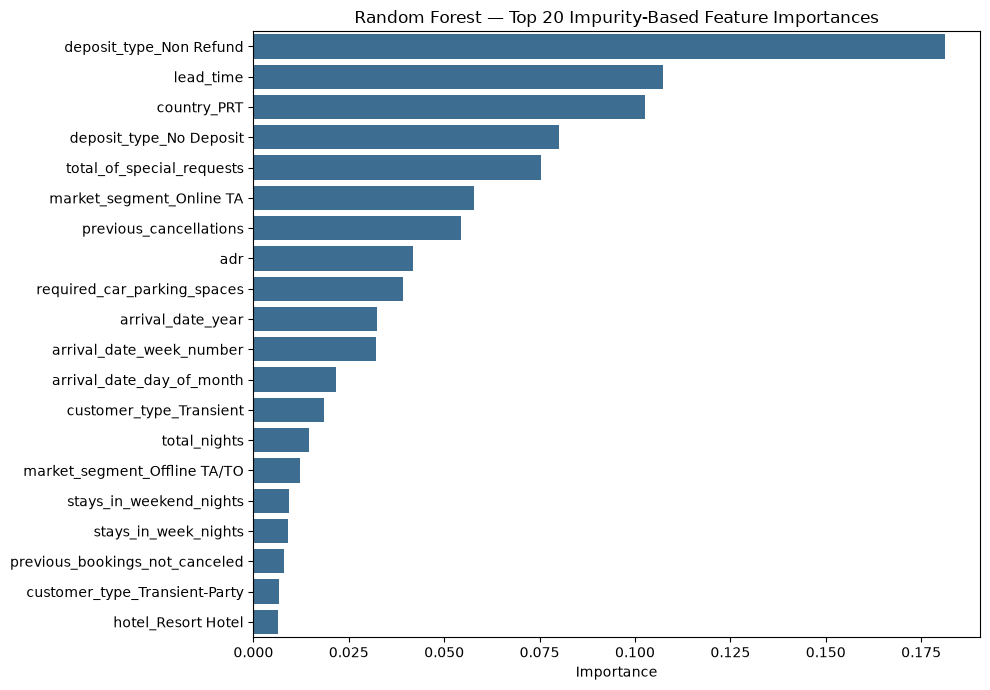

In [12]:
if random_forest is None:
    print("Complete TODO 4 first.")
else:
    # TODO 7: Replace None with the fitted forest's feature_importances_ attribute.
    FOREST_IMPORTANCES = random_forest.feature_importances_

    if FOREST_IMPORTANCES is None:
        print("TODO 7: Read feature importances from the fitted forest.")
    else:
        feature_importance = (
            pd.DataFrame({
                "feature": feature_names,
                "importance": FOREST_IMPORTANCES,
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )
        feature_importance.insert(0, "rank", np.arange(1, len(feature_importance) + 1))
        top_features = feature_importance.head(20)
        display(top_features)

        plt.figure(figsize=(10, 7))
        sns.barplot(data=top_features, x="importance", y="feature", color="#2f6f9f")
        plt.title("Random Forest — Top 20 Impurity-Based Feature Importances")
        plt.xlabel("Importance")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()


**Interpret carefully:** Which features appear influential, and what can you *not* conclude from this chart?

## FEATURE IMPORTANCE ANALYSIS
The most influential features include non-refundable deposit status, lead time, bookings from Portugal, total special requests, no-deposit status, online travel-agent market segment, previous cancellations, average daily rate, and required parking spaces. These features appear to contribute strongly to the random forest’s predictions. However, the chart does not show whether each feature increases or decreases cancellation probability, and it does not prove that any feature causes cancellations. Correlated features may divide or distort their importance, and impurity-based importance can favor features that provide more possible split points. Permutation importance or SHAP analysis would provide additional evidence

<details>
<summary>Suggested caution</summary>

Importance shows how much a feature reduced impurity across the fitted forest. It does not prove causation, reveal whether the effect increases or decreases cancellation risk, or guarantee stability under correlated features. Permutation importance or SHAP can provide complementary evidence later.
</details>


## 11. Save reproducible outputs


### TODO 8 — Save the selected tree candidate and reports


In [13]:
required_objects = ["model_comparison", "overfitting_check", "feature_importance"]
if any(name not in globals() for name in required_objects):
    print("Complete TODOs 1–7 first.")
else:
    # TODO 8: Replace None with the fitted model selected for the next milestone.
    MODEL_TO_SAVE = random_forest

    if MODEL_TO_SAVE is None:
        print("TODO 8: Choose the fitted tree-model candidate to save.")
    else:
        joblib.dump(MODEL_TO_SAVE, MODELS_DIR / "random_forest_candidate.joblib")
        model_comparison.to_csv(
            REPORTS_DIR / "milestone_05_model_comparison.csv", index=False
        )
        overfitting_check.to_csv(
            REPORTS_DIR / "milestone_05_overfitting_check.csv", index=False
        )
        feature_importance.to_csv(
            REPORTS_DIR / "milestone_05_feature_importance.csv", index=False
        )
        print("Tree-model candidate and three Milestone 5 reports saved.")


Tree-model candidate and three Milestone 5 reports saved.


In [14]:
model_path = MODELS_DIR / "random_forest_candidate.joblib"
report_paths = [
    REPORTS_DIR / "milestone_05_model_comparison.csv",
    REPORTS_DIR / "milestone_05_overfitting_check.csv",
    REPORTS_DIR / "milestone_05_feature_importance.csv",
]
if model_path.exists() and all(path.exists() for path in report_paths):
    assert set(model_comparison["model"]) == {
        "Logistic regression", "Decision tree", "Random forest"
    }
    assert model_comparison["roc_auc"].between(0, 1).all()
    assert np.isclose(feature_importance["importance"].sum(), 1.0)
    assert random_forest.n_features_in_ == len(feature_names)
    print("Milestone 5 validation checks passed.")
else:
    print("Complete TODO 8 and save all outputs first.")


Milestone 5 validation checks passed.


## Expected validation result range

Small software-version differences are acceptable. With the recommended settings, results should be approximately:

| Model | Accuracy | Precision | Recall | F1 | ROC AUC |
|---|---:|---:|---:|---:|---:|
| Logistic regression | 0.796 | 0.763 | 0.701 | 0.731 | 0.875 |
| Decision tree | 0.797 | 0.714 | 0.812 | 0.760 | 0.885 |
| Random forest | 0.811 | 0.763 | 0.756 | 0.760 | 0.899 |

If your values differ substantially, stop and check the split dates, feature manifest, saved preprocessing pipeline, and model settings.


## Interview-ready summary

Complete this after the notebook runs:

> I compared a controlled decision tree and random forest with a saved logistic-regression baseline using the same chronological validation design. The tree models captured nonlinear patterns and improved validation ranking performance. I quantified overfitting with train-versus-validation F1 and ROC AUC gaps, used feature importance as descriptive—not causal—evidence, and kept the test set sealed. I selected the random forest as the next candidate because it produced the strongest validation ROC AUC while maintaining competitive F1.


## Questions you should be ready to answer

1. How does a decision tree choose a split?
2. What do `max_depth` and `min_samples_leaf` control?
3. Why can a deep tree overfit?
4. How does bagging make a random forest more stable?
5. What does `max_features` change across trees?
6. Why compare both training and validation metrics?
7. Why can ROC AUC and F1 prefer different models?
8. What are the limitations of impurity-based feature importance?
9. Why was the test set still sealed?

## Interview-Ready Answers
1. How does a decision tree choose a split?
A decision tree tests different features and thresholds and selects the split that produces the greatest reduction in impurity. For classification, impurity is commonly measured using Gini impurity or entropy. The goal is to create child nodes containing more clearly separated classes, such as canceled versus not canceled bookings.
2. What do max_depth and min_samples_leaf control?
   - max_depth limits how many levels the tree can grow.
   - min_samples_leaf specifies the minimum number of training observations required in each final leaf.
Both parameters regularize the tree. Lower depth and larger leaves create simpler, more generalizable rules, while greater depth and smaller leaves allow more detailed—but potentially unstable—rules.
3. Why can a deep tree overfit?
A deep tree can continue splitting until it models small groups, noise, and unusual cases in the training data. This can produce excellent training performance but weaker validation performance because those highly specific rules may not apply to future bookings.
4. How does bagging make a random forest more stable?
Bagging trains many trees using different bootstrap samples of the training data. Their predictions are then averaged or voted together. Errors made by individual trees can cancel one another out, reducing variance and making the ensemble less sensitive to small changes in the training data.
5. What does max_features change across trees?
max_features controls how many randomly selected features each tree considers when choosing a split. Restricting this number creates more variety among the trees. Less-correlated trees generally produce a stronger ensemble when their predictions are averaged.
In this project, max_features=0.5 allowed each split to consider half of the transformed features.
6. Why compare both training and validation metrics?
Training metrics show how well the model fits data it has already seen. Validation metrics estimate how well it generalizes to later, unseen bookings.
A large training-versus-validation gap suggests overfitting. In this project, the random forest had the strongest validation ROC AUC but also the largest performance gap, indicating that further regularization should be investigated.
7. Why can ROC AUC and F1 prefer different models?
ROC AUC evaluates how well predicted probabilities rank positive cases above negative cases across all possible classification thresholds.
F1 evaluates the balance between precision and recall at one selected threshold—normally 0.50.
Therefore, a model can rank bookings very well overall and have a strong ROC AUC, while another model produces a slightly better precision-recall balance at the current threshold. Threshold optimization can change F1 without changing ROC AUC.
8. What are the limitations of impurity-based feature importance?
Impurity-based importance:
- Does not establish causation
- Does not reveal whether a feature raises or lowers cancellation risk
- Can favor continuous or high-cardinality features
- Can divide importance among correlated features
- May change across datasets or time periods
- Reflects the fitted model, not necessarily the true business process
Permutation importance and SHAP analysis can provide complementary explanations.
9. Why was the test set still sealed?
The test set was kept sealed because the validation set is used for model comparison, interpretation, and tuning. Evaluating the test set repeatedly would indirectly influence model decisions and create test-set leakage.
The test set should be opened only after the final model, hyperparameters, features, and threshold have been selected. This preserves an unbiased estimate of performance on genuinely unseen future bookings.


## Milestone 5 completion checklist

- [x] Loaded the cleaned data and earlier model artifacts
- [x] Recreated the chronological train/validation/test boundaries
- [x] Kept the test set sealed
- [x] Trained a regularized decision tree
- [x] Visualized the tree's first three levels
- [x] Trained a reproducible random forest
- [x] Compared both models with logistic regression
- [x] Measured train-versus-validation performance gaps
- [x] Interpreted feature importance with appropriate caveats
- [x] Saved the candidate model and three reports
- [x] Can explain the model choice in business language
